In [1]:
import warnings
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
file1 = "XNAS-20250109-DBURTAEFBS/xnas-itch-20241209-20241231.mbp-10.csv"
file2 = "XNAS-20250109-DBURTAEFBS/xnas-itch-20250101-20250108.mbp-10.csv"
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
combined_df = pd.concat([df1, df2], ignore_index=True)
combined_df.head()

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-12-09T09:00:00.025831166Z,2024-12-09T09:00:00.025645276Z,10,2,38,A,N,0,258.90,41,...,0,0,0,NaN,NaN,0,0,0,0,AAPL
1,2024-12-09T09:00:00.032236496Z,2024-12-09T09:00:00.032067146Z,10,2,38,A,B,0,217.00,100,...,0,0,0,NaN,NaN,0,0,0,0,AAPL
2,2024-12-09T09:00:00.037654835Z,2024-12-09T09:00:00.037487677Z,10,2,16244,A,N,0,960.00,25,...,0,0,0,NaN,NaN,0,0,0,0,TSLA
3,2024-12-09T09:00:00.038696269Z,2024-12-09T09:00:00.038529502Z,10,2,16244,A,B,0,392.43,256,...,0,0,0,NaN,NaN,0,0,0,0,TSLA
4,2024-12-09T09:00:00.038715098Z,2024-12-09T09:00:00.038548379Z,10,2,16244,A,A,0,402.77,256,...,0,0,0,NaN,NaN,0,0,0,0,TSLA


In [3]:
levels = range(5) # array of the 5 levels to analyze

In [4]:
aapl_data = combined_df[combined_df['symbol'] == 'AAPL']
aapl_data = aapl_data[aapl_data['action'].isin(['A', 'T'])]
columns_to_keep = ['ts_event'] + [
    f'{header}_{i:02}'
    for i in range(5) # 00 to 04
    for header in ['bid_px', 'ask_px', 'bid_sz', 'ask_sz']
]
aapl_simplified = aapl_data[columns_to_keep]
aapl_simplified.loc[:, 'ts_event'] = pd.to_datetime(aapl_simplified['ts_event'])
aapl_simplified.set_index("ts_event", inplace=True)
aapl_simplified = aapl_simplified.resample("T").mean().reset_index()
aapl_simplified.head()

,ts_event,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_px_01,ask_px_01,bid_sz_01,ask_sz_01,bid_px_02,...,bid_sz_02,ask_sz_02,bid_px_03,ask_px_03,bid_sz_03,ask_sz_03,bid_px_04,ask_px_04,bid_sz_04,ask_sz_04
0,2024-12-09 09:00:00+00:00,241.599811,244.726667,42.222222,23.055556,240.171923,245.098600,62.240741,45.407407,237.706939,...,91.666667,39.074074,236.282667,245.255106,125.537037,23.333333,233.748095,245.776957,54.203704,33.759259
1,2024-12-09 09:01:00+00:00,242.309355,242.795161,22.516129,235.870968,242.046129,242.831613,11.096774,91.741935,241.814194,...,60.161290,28.935484,241.391613,243.156129,50.645161,42.354839,240.934194,243.712903,42.129032,291.903226
2,2024-12-09 09:02:00+00:00,242.541404,242.722456,161.701754,85.736842,242.366667,242.811930,57.070175,47.438596,242.143158,...,22.105263,49.350877,241.904386,243.011754,40.000000,177.596491,241.502105,243.204912,55.473684,405.543860
3,2024-12-09 09:03:00+00:00,242.668684,242.994474,99.105263,69.236842,242.520526,243.101579,114.263158,185.815789,242.234737,...,72.657895,818.078947,241.976316,243.502895,38.026316,28.105263,241.622632,244.012368,55.842105,11.131579
4,2024-12-09 09:04:00+00:00,242.530909,242.843333,52.545455,29.818182,242.201212,242.978182,22.939394,104.393939,242.040909,...,30.696970,627.818182,241.904848,243.387879,27.848485,280.787879,241.529394,243.793030,76.909091,92.090909


In [5]:
def calculate_ofi(data, levels=5):
    ofi_arr = []
    for n in range(levels):
        bid_px_col = f"bid_px_{n:02d}"
        ask_px_col = f"ask_px_{n:02d}"
        bid_sz_col = f"bid_sz_{n:02d}"
        ask_sz_col = f"ask_sz_{n:02d}"

        buy_vol_change = np.sign(data[bid_px_col].diff()) * data[bid_sz_col].diff()
        sell_vol_change = np.sign(data[ask_px_col].diff()) * data[ask_sz_col].diff()
        ofi = buy_vol_change - sell_vol_change
        ofi_arr.append(ofi)

    ofi_df = pd.concat(ofi_arr, axis=1)
    ofi_df.columns = [f"OFI_{i:02d}" for i in range(levels)]
    ofi_df['ts_event'] = data['ts_event'].values
    return ofi_df

In [6]:
aapl_ofi_data = calculate_ofi(aapl_simplified)
aapl_ofi_data.head(25)

,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,ts_event
0,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:00:00
1,193.109319,-4.809438,-41.643967,-55.870370,246.069295,2024-12-09 09:01:00
2,-10.948500,1.670062,-17.640634,124.596491,126.985286,2024-12-09 09:02:00
3,-46.096491,-81.184211,-718.175439,147.517544,394.780702,2024-12-09 09:03:00
4,7.141148,9.901914,-148.299841,262.860447,59.892344,2024-12-09 09:04:00
5,77.727273,-65.824111,-489.884717,356.908432,207.100791,2024-12-09 09:05:00
6,9.939394,9.854414,-142.094203,-107.940053,276.312912,2024-12-09 09:06:00
7,-181.233512,34.739750,-43.568627,-504.905526,426.442068,2024-12-09 09:07:00
8,353.700190,60.734345,-41.641366,-227.673624,465.493359,2024-12-09 09:08:00
9,-1.364055,253.177419,70.069124,-10.639401,-456.781106,2024-12-09 09:09:00


In [7]:
def perform_pca_on_ofi(data, levels=5):
    result = data.copy()
    result.set_index('ts_event', inplace=True)
    ofi_cols = [f'OFI_{m:02d}' for m in range(levels)]
    ofi_data = result[ofi_cols].dropna()
    pca = PCA(n_components=1)
    pca_result = pca.fit_transform(ofi_data)
    result.loc[ofi_data.index, 'PCA_OFI'] = pca_result.flatten()
    result = result.dropna(subset=['PCA_OFI'])
    result = result.reset_index();
    return result

In [8]:
aapl_pca_data = perform_pca_on_ofi(aapl_ofi_data)
aapl_pca_data

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI
0,2024-12-09 09:01:00,193.109319,-4.809438,-41.643967,-55.870370,246.069295,-189.761689
1,2024-12-09 09:02:00,-10.948500,1.670062,-17.640634,124.596491,126.985286,-82.560676
2,2024-12-09 09:03:00,-46.096491,-81.184211,-718.175439,147.517544,394.780702,-177.753042
3,2024-12-09 09:04:00,7.141148,9.901914,-148.299841,262.860447,59.892344,-113.011972
4,2024-12-09 09:05:00,77.727273,-65.824111,-489.884717,356.908432,207.100791,-255.049439
...,...,...,...,...,...,...,...
17336,2025-01-08 23:37:00,-108.000000,7.000000,-2.000000,-1.000000,2.000000,9.667608
17337,2025-01-08 23:49:00,-1776.666667,669.333333,210.666667,885.111111,-33.000000,1402.583744
17338,2025-01-08 23:50:00,0.000000,0.000000,157.000000,-2.000000,-1.000000,-53.643845
17339,2025-01-08 23:55:00,0.000000,0.000000,0.000000,0.000000,0.000000,-61.639088


In [9]:
def calculate_returns(data, pca_data):
    data = data.copy()
    pca_data = pca_data.copy()
    data['ts_event'] = pd.to_datetime(data['ts_event']).dt.tz_localize(None)
    pca_data['ts_event'] = pd.to_datetime(pca_data['ts_event']).dt.tz_localize(None)
    data = data.sort_values(by='ts_event')

    data['mid_price'] = (data['bid_px_00'] + data['ask_px_00']) / 2
    data['log_return_1min'] = np.log(data['mid_price']).diff(1)

    return_data = (
        data.resample('1min', on='ts_event')['log_return_1min']
        .last()
        .reset_index()
        .rename(columns={'ts_event': 'ts_event_min'})
    )

    merged_data = pca_data.merge(
        return_data,
        how='inner',
        left_on='ts_event',
        right_on='ts_event_min'
    )
    
    merged_data = merged_data.drop(columns=['ts_event_min'])

    return merged_data

In [10]:
aapl_returns = calculate_returns(aapl_simplified, aapl_pca_data)
aapl_returns

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI,log_return_1min
0,2024-12-09 09:01:00,193.109319,-4.809438,-41.643967,-55.870370,246.069295,-189.761689,-0.002516
1,2024-12-09 09:02:00,-10.948500,1.670062,-17.640634,124.596491,126.985286,-82.560676,0.000328
2,2024-12-09 09:03:00,-46.096491,-81.184211,-718.175439,147.517544,394.780702,-177.753042,0.000823
3,2024-12-09 09:04:00,7.141148,9.901914,-148.299841,262.860447,59.892344,-113.011972,-0.000595
4,2024-12-09 09:05:00,77.727273,-65.824111,-489.884717,356.908432,207.100791,-255.049439,-0.000975
...,...,...,...,...,...,...,...,...
17336,2025-01-08 23:37:00,-108.000000,7.000000,-2.000000,-1.000000,2.000000,9.667608,0.000144
17337,2025-01-08 23:49:00,-1776.666667,669.333333,210.666667,885.111111,-33.000000,1402.583744,-0.000248
17338,2025-01-08 23:50:00,0.000000,0.000000,157.000000,-2.000000,-1.000000,-53.643845,0.000000
17339,2025-01-08 23:55:00,0.000000,0.000000,0.000000,0.000000,0.000000,-61.639088,0.000000


In [11]:
def contemporaneous_cross_impact(returns_df, lag=0):
    df = returns_df.copy()
    focus = 'PCA_OFI'
    
    if lag > 0:
        lagged = f'PCA_OFI_lag{lag}'
        df[lagged] = df['PCA_OFI'].shift(lag)
    else:
        lagged = 'PCA_OFI'

    df = df.dropna(subset=['log_return_1min', lagged])
    
    X = df[[lagged]]
    y = df['log_return_1min']
    
    model = LinearRegression()
    model.fit(X, y)
    
    df['predicted_return'] = model.predict(X)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(df[lagged], df['log_return_1min'], alpha=0.5, label='Actual Data')
    ax.plot(df[lagged], df['predicted_return'], color='red', label='Regression Line')
    ax.set_xlabel(lagged)
    ax.set_ylabel('Log Return (1 min)')
    ax.set_title(f'Regression of Log Returns on {lagged}')
    ax.legend()

    plot = fig
    
    r2 = model.score(X, y)
    coefs = model.coef_
    results = {
        "r2": r2,
        "coef_PCA_OFI": coefs[0],
    }
    return results, plot

In [12]:
r2_dict = {}

({'r2': 3.2789674101474375e-06,
  'coef_PCA_OFI': np.float64(-2.8115001900224057e-10)},
 <Figure size 1000x600 with 1 Axes>)

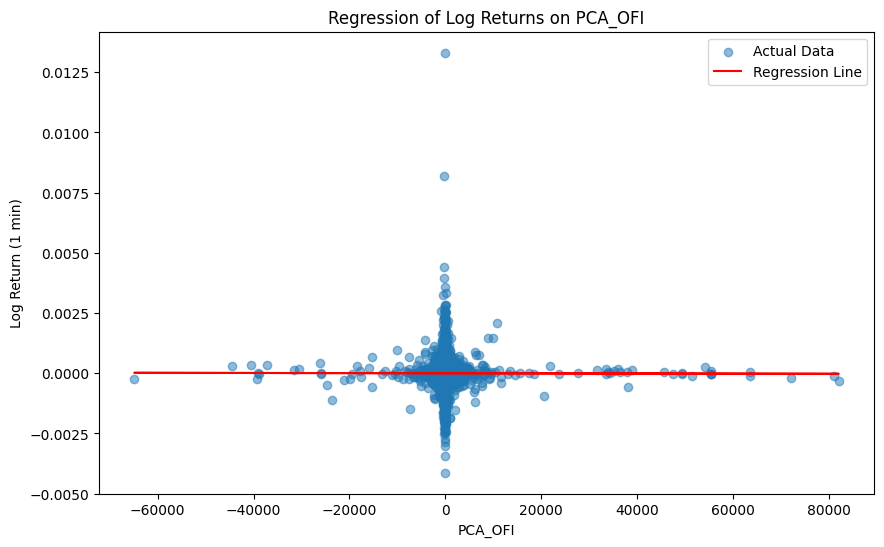

In [13]:
aapl_cont_cross = contemporaneous_cross_impact(aapl_returns)
aapl_r2 = []
aapl_r2.append(aapl_cont_cross[0])
aapl_cont_cross

#### <u>1 min and 5 min lag</u>

({'r2': 0.0002096296911113793,
  'coef_PCA_OFI': np.float64(-2.2430753667510165e-09)},
 <Figure size 1000x600 with 1 Axes>)

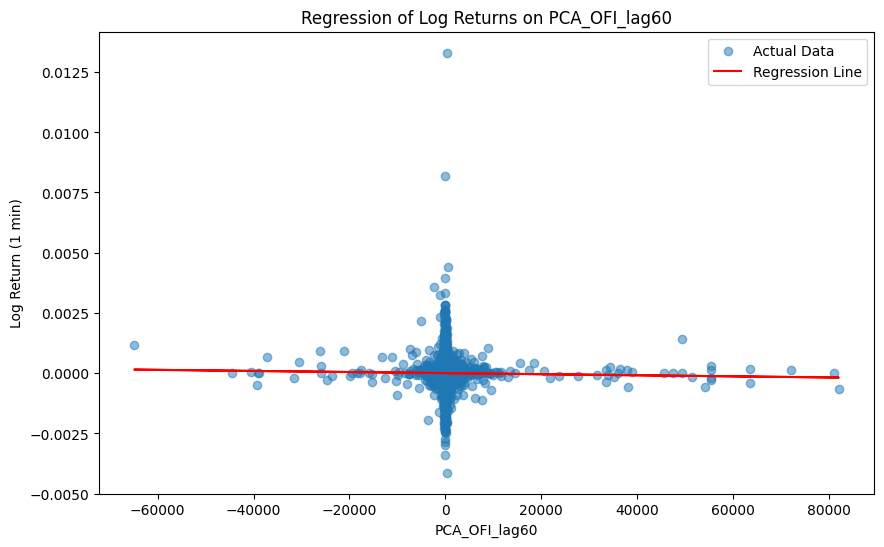

In [14]:
aapl_cont_cross_1min = contemporaneous_cross_impact(aapl_returns, 60)
aapl_r2.append(aapl_cont_cross_1min[0])
aapl_cont_cross_1min

({'r2': 0.0001301548086392046,
  'coef_PCA_OFI': np.float64(1.7663982824331818e-09)},
 <Figure size 1000x600 with 1 Axes>)

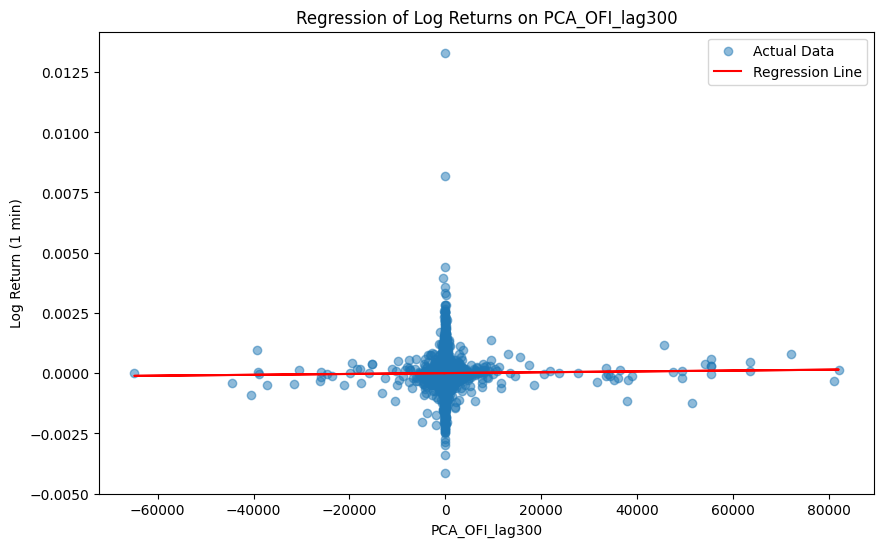

In [15]:
aapl_cont_cross_5min = contemporaneous_cross_impact(aapl_returns, 300)
aapl_r2.append(aapl_cont_cross_5min[0])
r2_dict['AAPL'] = aapl_r2
aapl_cont_cross_5min

In [16]:
def plot_heatmap(df, title):
    corr = df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(title)
    plt.show()

def plot_scatter(df, x, y, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x, y=y, alpha=0.6)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

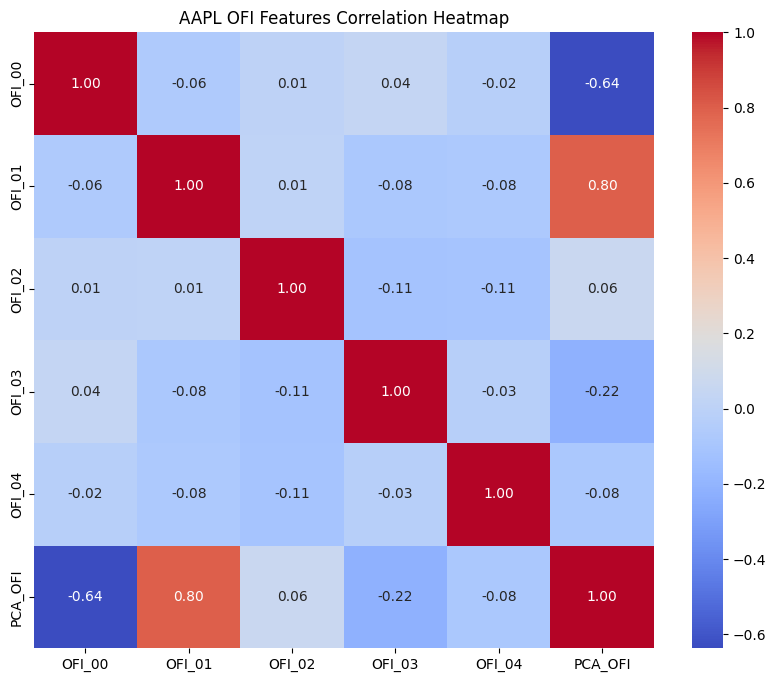

In [17]:
aapl_df = aapl_returns.dropna(subset=[f'OFI_{i:02d}' for i in range(5)])
ofi_cols_aapl = [f'OFI_{i:02d}' for i in range(5)] + ["PCA_OFI"]
aapl_df = aapl_df[ofi_cols_aapl].dropna()
plot_heatmap(aapl_df, "AAPL OFI Features Correlation Heatmap")

# <u>**TSLA**</u>

In [18]:
tsla_data = combined_df[combined_df['symbol'] == 'TSLA']
tsla_data = tsla_data[tsla_data['action'].isin(['A', 'T'])]
columns_to_keep = ['ts_event'] + [
    f'{header}_{i:02}'
    for i in range(5)
    for header in ['bid_px', 'ask_px', 'bid_sz', 'ask_sz']
]
tsla_simplified = tsla_data[columns_to_keep]
tsla_simplified.loc[:, 'ts_event'] = pd.to_datetime(tsla_simplified['ts_event'])
tsla_simplified.set_index("ts_event", inplace=True)
tsla_simplified = tsla_simplified.resample("T").mean().reset_index()
tsla_simplified.head()

,ts_event,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_px_01,ask_px_01,bid_sz_01,ask_sz_01,bid_px_02,...,bid_sz_02,ask_sz_02,bid_px_03,ask_px_03,bid_sz_03,ask_sz_03,bid_px_04,ask_px_04,bid_sz_04,ask_sz_04
0,2024-12-09 09:00:00+00:00,396.504700,397.760504,187.907615,170.842665,396.223079,398.241519,260.895857,130.832027,395.970107,...,291.247480,311.587906,395.780191,398.406910,231.430571,362.097424,395.552838,401.806929,273.640538,286.321389
1,2024-12-09 09:01:00+00:00,396.557899,396.856254,119.739414,99.374593,396.469935,396.934528,235.203583,172.477199,396.392818,...,331.552117,446.682410,396.305326,397.121368,333.741042,728.509772,396.219463,397.228616,389.120521,842.490228
2,2024-12-09 09:02:00+00:00,395.890727,396.221813,102.727497,94.983970,395.792491,396.330863,124.658446,211.913687,395.694217,...,197.013564,307.971640,395.621973,396.524414,317.680641,546.200986,395.549507,396.642959,363.033292,772.711467
3,2024-12-09 09:03:00+00:00,396.019105,396.197068,279.567901,216.503086,395.883333,396.342623,111.006173,761.416667,395.802006,...,43.959877,933.601852,395.755340,396.625093,75.975309,1180.719136,395.684969,396.768241,502.342593,913.108025
4,2024-12-09 09:04:00+00:00,396.554009,396.912922,129.660793,138.992658,396.478326,397.031336,131.170338,227.883994,396.409398,...,252.345081,367.851689,396.366329,397.213759,253.982379,522.474302,396.327225,397.352349,410.806167,531.170338


In [19]:
tsla_ofi_data = calculate_ofi(tsla_simplified)
tsla_ofi_data.head(25)

,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,ts_event
0,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:00:00
1,-139.636273,15.952898,175.399141,468.722819,671.648823,2024-12-09 09:01:00
2,12.621294,149.981625,-4.172217,-166.248384,-43.691532,2024-12-09 09:02:00
3,298.359520,-563.155253,-778.683899,-876.223482,-1.087257,2024-12-09 09:03:00
4,-72.396680,553.696837,774.135367,836.251904,290.401262,2024-12-09 09:04:00
5,41.058414,533.733804,318.444473,149.379477,154.192986,2024-12-09 09:05:00
6,1019.248170,-409.552938,133.395189,296.976236,543.560348,2024-12-09 09:06:00
7,405.025501,-190.922140,-416.348048,-177.661695,825.913150,2024-12-09 09:07:00
8,-1570.949350,-12.151956,-46.592036,-474.780917,-160.966271,2024-12-09 09:08:00
9,6.186455,149.221990,440.707776,51.290134,-292.752926,2024-12-09 09:09:00


In [20]:
tsla_pca_data = perform_pca_on_ofi(tsla_ofi_data)
tsla_pca_data

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI
0,2024-12-09 09:01:00,-139.636273,15.952898,175.399141,468.722819,671.648823,785.263287
1,2024-12-09 09:02:00,12.621294,149.981625,-4.172217,-166.248384,-43.691532,-90.452505
2,2024-12-09 09:03:00,298.359520,-563.155253,-778.683899,-876.223482,-1.087257,-829.912200
3,2024-12-09 09:04:00,-72.396680,553.696837,774.135367,836.251904,290.401262,905.290225
4,2024-12-09 09:05:00,41.058414,533.733804,318.444473,149.379477,154.192986,287.487219
...,...,...,...,...,...,...,...
18754,2025-01-08 23:55:00,-216.428571,-423.714286,464.285714,274.142857,103.000000,471.160891
18755,2025-01-08 23:56:00,-150.924370,122.260504,34.983193,-21.907563,111.714286,170.949838
18756,2025-01-08 23:57:00,-4.063725,442.404412,112.296569,-231.127451,-213.875000,-168.020551
18757,2025-01-08 23:58:00,78.967949,-25.368590,-9.535256,-27.814103,-191.413462,-162.549382


In [21]:
tsla_returns = calculate_returns(tsla_simplified, tsla_pca_data)
tsla_returns

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI,log_return_1min
0,2024-12-09 09:01:00,-139.636273,15.952898,175.399141,468.722819,671.648823,785.263287,-0.001072
1,2024-12-09 09:02:00,12.621294,149.981625,-4.172217,-166.248384,-43.691532,-90.452505,-0.001642
2,2024-12-09 09:03:00,298.359520,-563.155253,-778.683899,-876.223482,-1.087257,-829.912200,0.000131
3,2024-12-09 09:04:00,-72.396680,553.696837,774.135367,836.251904,290.401262,905.290225,0.001578
4,2024-12-09 09:05:00,41.058414,533.733804,318.444473,149.379477,154.192986,287.487219,0.000095
...,...,...,...,...,...,...,...,...
18754,2025-01-08 23:55:00,-216.428571,-423.714286,464.285714,274.142857,103.000000,471.160891,-0.000022
18755,2025-01-08 23:56:00,-150.924370,122.260504,34.983193,-21.907563,111.714286,170.949838,0.000138
18756,2025-01-08 23:57:00,-4.063725,442.404412,112.296569,-231.127451,-213.875000,-168.020551,0.000257
18757,2025-01-08 23:58:00,78.967949,-25.368590,-9.535256,-27.814103,-191.413462,-162.549382,-0.000193


({'r2': 3.818580372194624e-05,
  'coef_PCA_OFI': np.float64(-7.746378262920397e-09)},
 <Figure size 1000x600 with 1 Axes>)

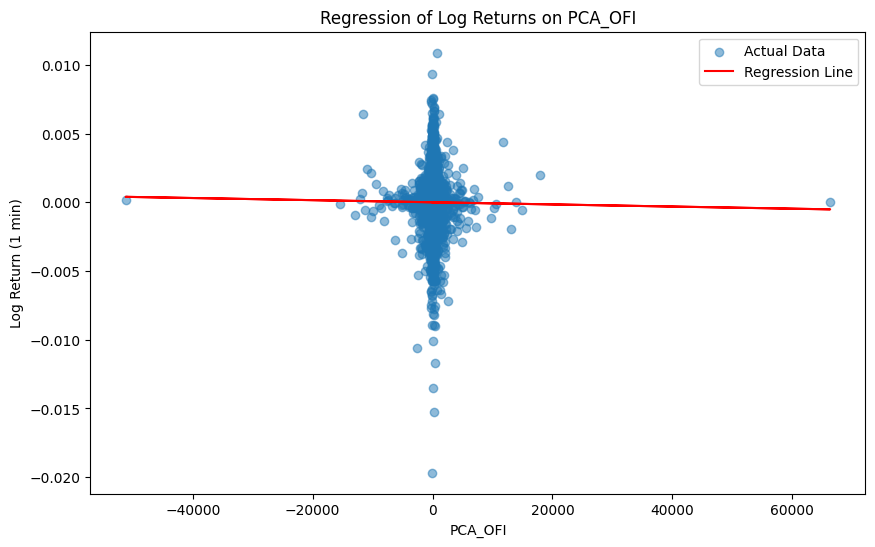

In [22]:
tsla_cont_cross = contemporaneous_cross_impact(tsla_returns)
tsla_r2 = []
tsla_r2.append(tsla_cont_cross[0])
tsla_cont_cross

({'r2': 2.8891339734937738e-05,
  'coef_PCA_OFI': np.float64(-6.734770458447938e-09)},
 <Figure size 1000x600 with 1 Axes>)

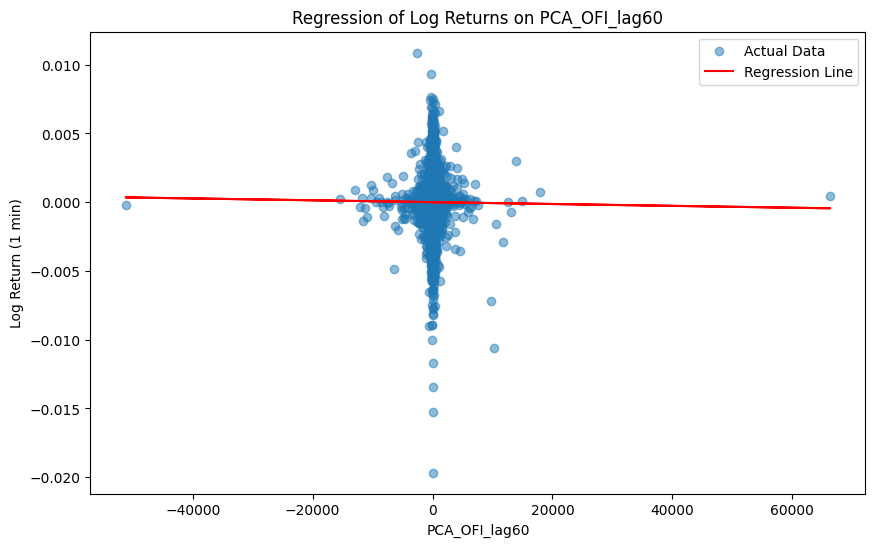

In [23]:
tsla_cont_cross_1min = contemporaneous_cross_impact(tsla_returns, 60)
tsla_r2.append(tsla_cont_cross_1min[0])
tsla_cont_cross_1min

({'r2': 4.089909901194844e-06,
  'coef_PCA_OFI': np.float64(2.530347891306303e-09)},
 <Figure size 1000x600 with 1 Axes>)

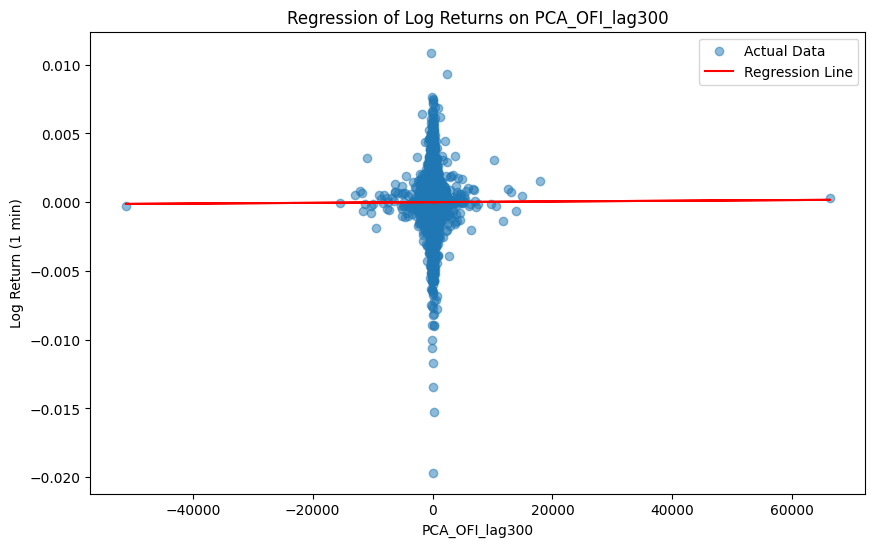

In [24]:
tsla_cont_cross_5min = contemporaneous_cross_impact(tsla_returns, 300)
tsla_r2.append(tsla_cont_cross_5min[0])
r2_dict['TSLA'] = tsla_r2
tsla_cont_cross_5min

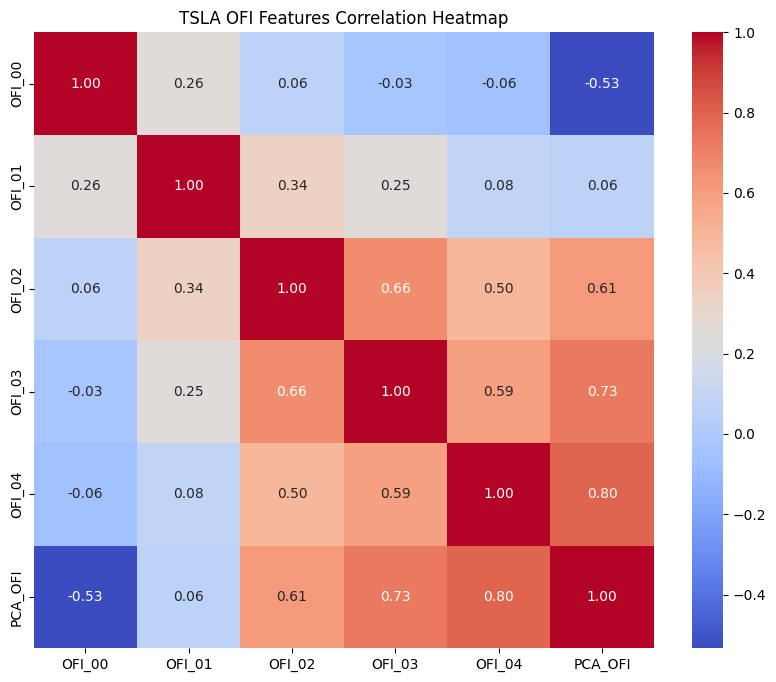

In [25]:
tsla_df = tsla_returns.dropna(subset=[f'OFI_{i:02d}' for i in range(5)])
ofi_cols_tsla = [f'OFI_{i:02d}' for i in range(5)] + ["PCA_OFI"]
tsla_df = tsla_df[ofi_cols_tsla].dropna()
plot_heatmap(tsla_df, "TSLA OFI Features Correlation Heatmap")

# <u>**COST**</u>

In [26]:
cost_data = combined_df[combined_df['symbol'] == 'COST']
cost_data = cost_data[cost_data['action'].isin(['A', 'T'])]
columns_to_keep = ['ts_event'] + [
    f'{header}_{i:02}'
    for i in range(5)
    for header in ['bid_px', 'ask_px', 'bid_sz', 'ask_sz']
]
cost_simplified = cost_data[columns_to_keep]
cost_simplified.loc[:, 'ts_event'] = pd.to_datetime(cost_simplified['ts_event'])
cost_simplified.set_index("ts_event", inplace=True)
cost_simplified = cost_simplified.resample("T").mean().reset_index()
cost_simplified.head()

,ts_event,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_px_01,ask_px_01,bid_sz_01,ask_sz_01,bid_px_02,...,bid_sz_02,ask_sz_02,bid_px_03,ask_px_03,bid_sz_03,ask_sz_03,bid_px_04,ask_px_04,bid_sz_04,ask_sz_04
0,2024-12-09 09:00:00+00:00,970.000000,1114.275000,2.000000,0.800000,900.000000,1114.945000,0.200000,0.800000,NaN,...,0.000000,0.200000,NaN,NaN,0.000000,0.0,NaN,NaN,0.000000,0.0
1,2024-12-09 09:01:00+00:00,987.920000,1024.246667,2.000000,1.777778,965.814444,1201.149375,1.722222,1.000000,937.222222,...,1.055556,0.111111,898.666667,NaN,0.833333,0.0,867.692308,NaN,0.722222,0.0
2,2024-12-09 09:02:00+00:00,993.029231,1007.273846,2.000000,1.961538,975.384615,1202.223200,4.692308,1.076923,953.076923,...,1.346154,0.115385,914.615385,NaN,1.000000,0.0,878.125000,NaN,0.923077,0.0
3,2024-12-09 09:03:00+00:00,994.808800,1017.134000,2.280000,1.880000,991.118800,1219.943478,3.640000,0.960000,983.008800,...,6.680000,0.040000,963.200000,NaN,2.320000,0.0,934.200000,NaN,1.080000,0.0
4,2024-12-09 09:04:00+00:00,994.767917,1008.335833,1.958333,1.958333,992.501250,1230.000000,3.375000,0.958333,989.166667,...,9.666667,0.000000,969.166667,NaN,1.958333,0.0,947.916667,NaN,1.000000,0.0


In [27]:
cost_ofi_data = calculate_ofi(cost_simplified)
cost_ofi_data.head(25)

,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,ts_event
0,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:00:00
1,0.977778,1.322222,NaN,NaN,NaN,2024-12-09 09:01:00
2,0.183761,2.893162,0.290598,NaN,NaN,2024-12-09 09:02:00
3,0.361538,-0.935385,5.333846,NaN,NaN,2024-12-09 09:03:00
4,0.400000,-0.263333,NaN,NaN,NaN,2024-12-09 09:04:00
5,-0.300725,2.373188,NaN,NaN,NaN,2024-12-09 09:05:00
6,-0.856683,9.586151,-20.119163,27.336554,0.851852,2024-12-09 09:06:00
7,-1.145503,11.698413,-3.113757,3.513228,0.148148,2024-12-09 09:07:00
8,-0.033835,-8.458647,-7.244361,6.879699,0.421053,2024-12-09 09:08:00
9,-0.105263,42.423977,0.447368,-38.818713,0.421053,2024-12-09 09:09:00


In [28]:
cost_pca_data = perform_pca_on_ofi(cost_ofi_data)
cost_pca_data

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI
0,2024-12-09 09:06:00,-0.856683,9.586151,-20.119163,27.336554,0.851852,-0.170883
1,2024-12-09 09:07:00,-1.145503,11.698413,-3.113757,3.513228,0.148148,6.419103
2,2024-12-09 09:08:00,-0.033835,-8.458647,-7.244361,6.879699,0.421053,-4.022218
3,2024-12-09 09:09:00,-0.105263,42.423977,0.447368,-38.818713,0.421053,7.417279
4,2024-12-09 09:10:00,-1.750000,44.256944,16.187500,-47.569444,-5.368056,17.686599
...,...,...,...,...,...,...,...
14457,2025-01-08 23:36:00,0.000000,0.000000,0.000000,0.000000,0.000000,3.067475
14458,2025-01-08 23:37:00,0.000000,0.000000,0.000000,0.000000,0.000000,3.067475
14459,2025-01-08 23:49:00,-0.000000,0.000000,0.000000,0.000000,0.000000,3.067475
14460,2025-01-08 23:58:00,0.000000,0.000000,0.000000,0.000000,0.000000,3.067475


In [29]:
cost_returns = calculate_returns(cost_simplified, cost_pca_data)
cost_returns

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI,log_return_1min
0,2024-12-09 09:06:00,-0.856683,9.586151,-20.119163,27.336554,0.851852,-0.170883,0.003452
1,2024-12-09 09:07:00,-1.145503,11.698413,-3.113757,3.513228,0.148148,6.419103,-0.000273
2,2024-12-09 09:08:00,-0.033835,-8.458647,-7.244361,6.879699,0.421053,-4.022218,-0.008366
3,2024-12-09 09:09:00,-0.105263,42.423977,0.447368,-38.818713,0.421053,7.417279,0.000073
4,2024-12-09 09:10:00,-1.750000,44.256944,16.187500,-47.569444,-5.368056,17.686599,-0.000040
...,...,...,...,...,...,...,...,...
14457,2025-01-08 23:36:00,0.000000,0.000000,0.000000,0.000000,0.000000,3.067475,0.000132
14458,2025-01-08 23:37:00,0.000000,0.000000,0.000000,0.000000,0.000000,3.067475,0.000000
14459,2025-01-08 23:49:00,-0.000000,0.000000,0.000000,0.000000,0.000000,3.067475,0.000000
14460,2025-01-08 23:58:00,0.000000,0.000000,0.000000,0.000000,0.000000,3.067475,0.000034


({'r2': 5.764322290824353e-06,
  'coef_PCA_OFI': np.float64(-1.302396721376078e-08)},
 <Figure size 1000x600 with 1 Axes>)

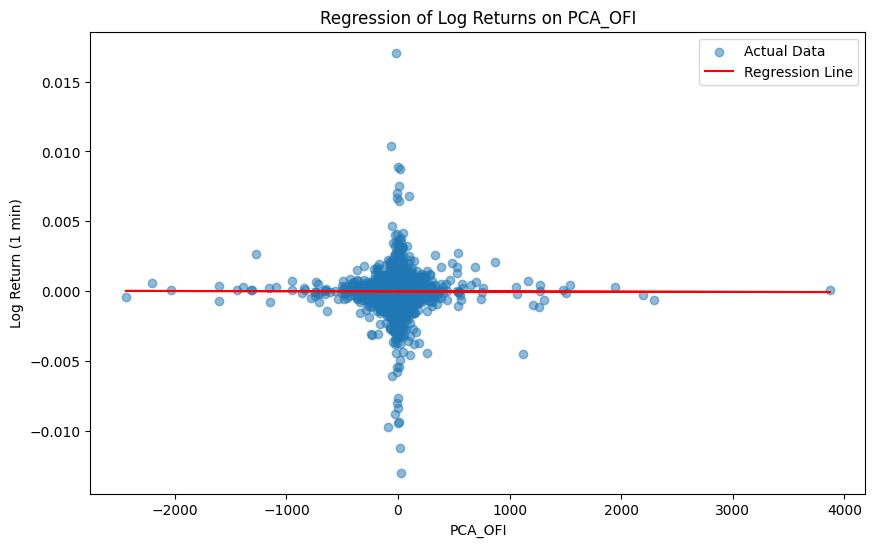

In [30]:
cost_cont_cross = contemporaneous_cross_impact(cost_returns)
cost_r2 = []
cost_r2.append(cost_cont_cross[0])
cost_cont_cross

({'r2': 6.9856542422863654e-06,
  'coef_PCA_OFI': np.float64(-1.368386963924903e-08)},
 <Figure size 1000x600 with 1 Axes>)

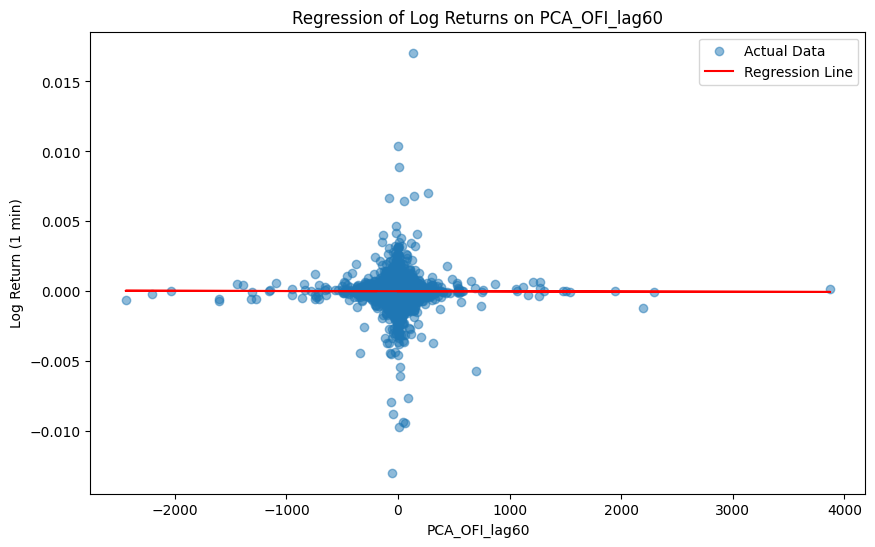

In [31]:
cost_cont_cross_1min = contemporaneous_cross_impact(cost_returns, 60)
cost_r2.append(cost_cont_cross_1min[0])
cost_cont_cross_1min

({'r2': 9.497538134839445e-07,
  'coef_PCA_OFI': np.float64(-5.080201798928093e-09)},
 <Figure size 1000x600 with 1 Axes>)

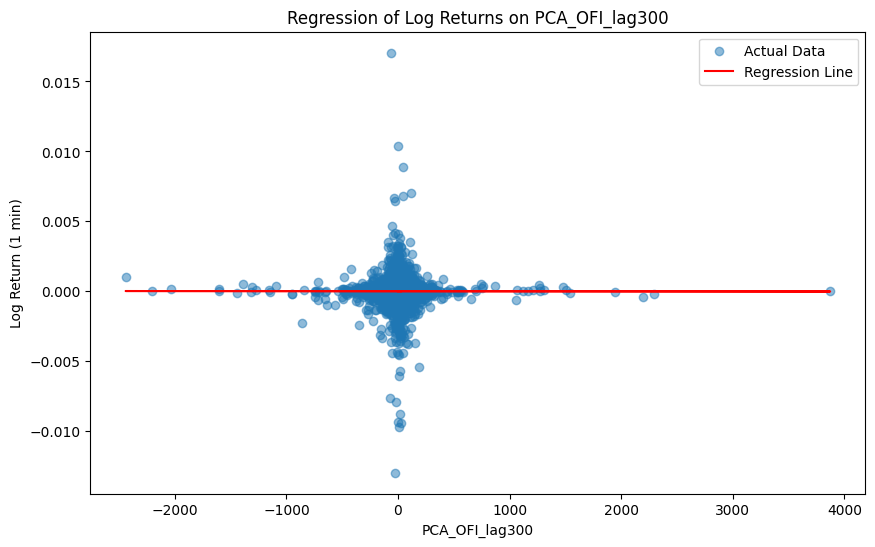

In [32]:
cost_cont_cross_5min = contemporaneous_cross_impact(cost_returns, 300)
cost_r2.append(cost_cont_cross_5min[0])
r2_dict['COST'] = cost_r2
cost_cont_cross_5min

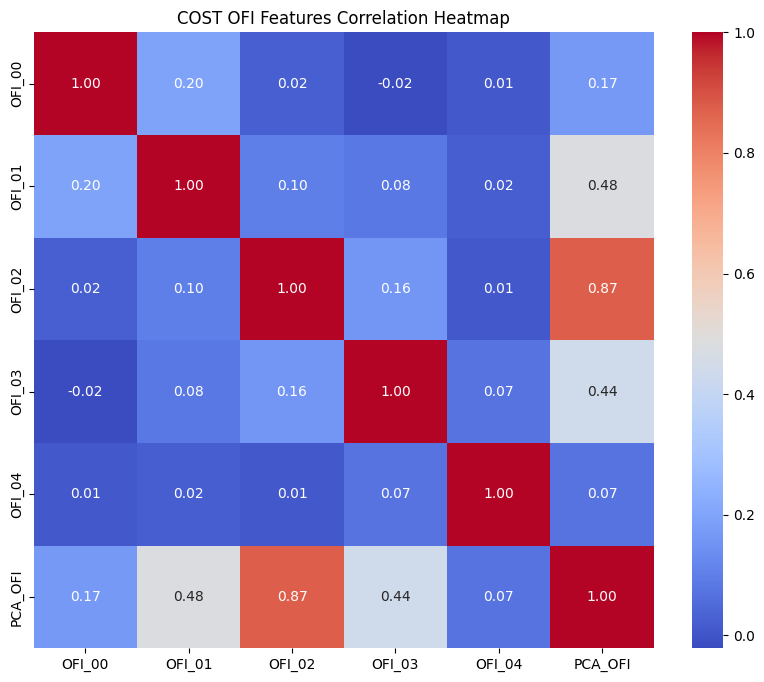

In [33]:
cost_df = cost_returns.dropna(subset=[f'OFI_{i:02d}' for i in range(5)])
ofi_cols_cost = [f'OFI_{i:02d}' for i in range(5)] + ["PCA_OFI"]
cost_df = cost_df[ofi_cols_cost].dropna()
plot_heatmap(cost_df, "COST OFI Features Correlation Heatmap")

# <u>**AEP**</u>

In [34]:
aep_data = combined_df[combined_df['symbol'] == 'AEP']
aep_data = aep_data[aep_data['action'].isin(['A', 'T'])]
columns_to_keep = ['ts_event'] + [
    f'{header}_{i:02}'
    for i in range(5)
    for header in ['bid_px', 'ask_px', 'bid_sz', 'ask_sz']
]
aep_simplified = aep_data[columns_to_keep]
aep_simplified.loc[:, 'ts_event'] = pd.to_datetime(aep_simplified['ts_event'])
aep_simplified.set_index("ts_event", inplace=True)
aep_simplified = aep_simplified.resample("T").mean().reset_index()
aep_simplified.head()

,ts_event,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_px_01,ask_px_01,bid_sz_01,ask_sz_01,bid_px_02,...,bid_sz_02,ask_sz_02,bid_px_03,ask_px_03,bid_sz_03,ask_sz_03,bid_px_04,ask_px_04,bid_sz_04,ask_sz_04
0,2024-12-09 09:18:00+00:00,NaN,96.93,0.0,1.0,NaN,97.98,0.0,0.5,NaN,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0
1,2024-12-09 09:19:00+00:00,95.19,98.59,50.0,25.0,NaN,NaN,0.0,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0
2,2024-12-09 09:20:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-12-09 09:21:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-12-09 09:22:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
aep_ofi_data = calculate_ofi(aep_simplified)
aep_ofi_data.head(25)

,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,ts_event
0,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:18:00
1,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:19:00
2,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:20:00
3,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:21:00
4,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:22:00
5,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:23:00
6,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:24:00
7,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:25:00
8,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:26:00
9,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:27:00


In [36]:
aep_pca_data = perform_pca_on_ofi(aep_ofi_data)
aep_pca_data

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI
0,2024-12-09 14:26:00,0.000000,0.000000,0.000000,0.000000,0.000000,9.931073
1,2024-12-09 14:27:00,-124.000000,-1156.000000,-100.000000,400.000000,0.000000,-437.080547
2,2024-12-09 14:28:00,-168.160714,-1107.196429,-971.142857,-860.089286,201.714286,-1453.234736
3,2024-12-09 14:31:00,23.626568,-27.882093,4.044435,8.170140,-321.913652,-59.083185
4,2024-12-09 14:32:00,33.698907,27.165209,133.861020,148.062477,-41.179599,170.829889
...,...,...,...,...,...,...,...
9180,2025-01-08 21:05:00,-43.000000,-56.000000,96.000000,-61.000000,-29.000000,-19.973277
9181,2025-01-08 21:06:00,1.000000,-56.000000,96.000000,-61.000000,-29.000000,1.189704
9182,2025-01-08 21:07:00,0.000000,0.000000,0.000000,0.000000,0.000000,9.931073
9183,2025-01-08 21:08:00,0.000000,0.000000,0.000000,0.000000,0.000000,9.931073


In [37]:
aep_returns = calculate_returns(aep_simplified, aep_pca_data)
aep_returns

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI,log_return_1min
0,2024-12-09 14:26:00,0.000000,0.000000,0.000000,0.000000,0.000000,9.931073,0.000000
1,2024-12-09 14:27:00,-124.000000,-1156.000000,-100.000000,400.000000,0.000000,-437.080547,0.001663
2,2024-12-09 14:28:00,-168.160714,-1107.196429,-971.142857,-860.089286,201.714286,-1453.234736,-0.010796
3,2024-12-09 14:31:00,23.626568,-27.882093,4.044435,8.170140,-321.913652,-59.083185,0.000089
4,2024-12-09 14:32:00,33.698907,27.165209,133.861020,148.062477,-41.179599,170.829889,-0.000508
...,...,...,...,...,...,...,...,...
9180,2025-01-08 21:05:00,-43.000000,-56.000000,96.000000,-61.000000,-29.000000,-19.973277,0.002405
9181,2025-01-08 21:06:00,1.000000,-56.000000,96.000000,-61.000000,-29.000000,1.189704,-0.002405
9182,2025-01-08 21:07:00,0.000000,0.000000,0.000000,0.000000,0.000000,9.931073,0.000000
9183,2025-01-08 21:08:00,0.000000,0.000000,0.000000,0.000000,0.000000,9.931073,0.000000


({'r2': 0.0020176979477943835,
  'coef_PCA_OFI': np.float64(1.1280192643369599e-07)},
 <Figure size 1000x600 with 1 Axes>)

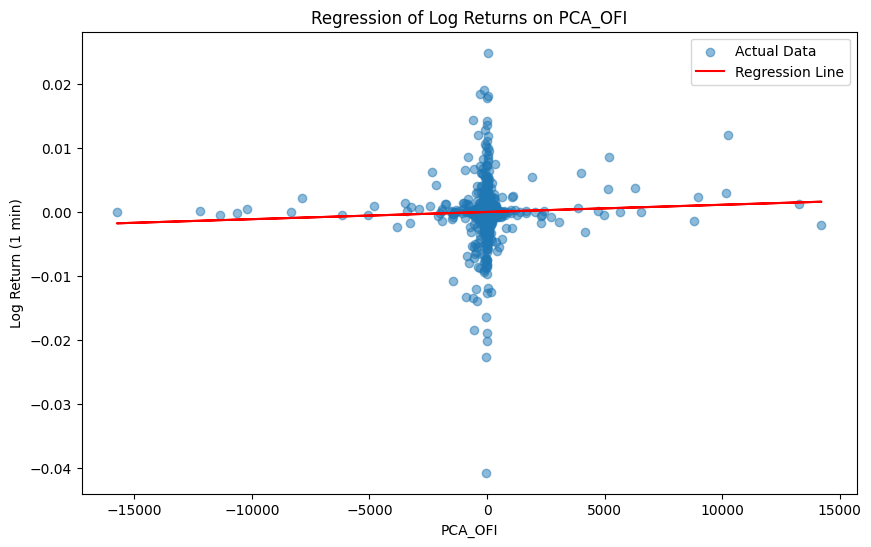

In [38]:
aep_cont_cross = contemporaneous_cross_impact(aep_returns)
aep_r2 = []
aep_r2.append(aep_cont_cross[0])
aep_cont_cross

({'r2': 0.0007738624801657545,
  'coef_PCA_OFI': np.float64(6.955475241388906e-08)},
 <Figure size 1000x600 with 1 Axes>)

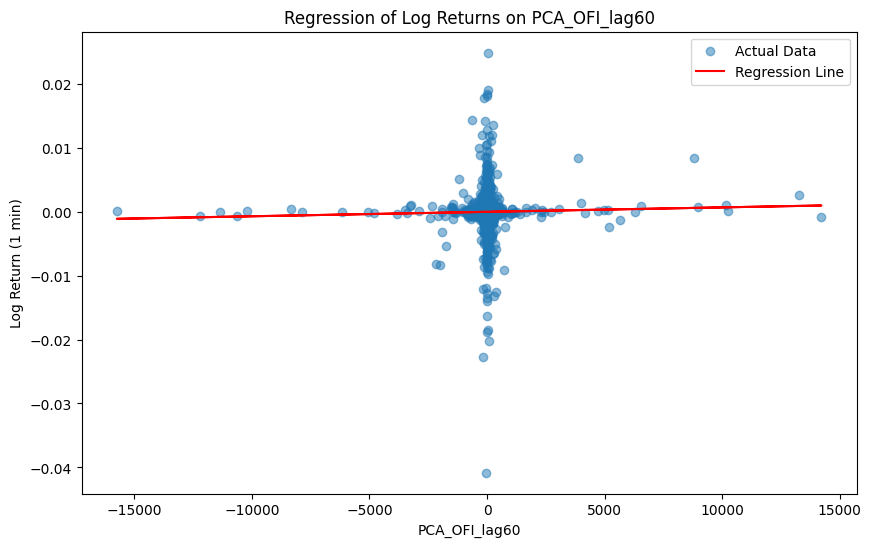

In [39]:
aep_cont_cross_1min = contemporaneous_cross_impact(aep_returns, 60)
aep_r2.append(aep_cont_cross_1min[0])
aep_cont_cross_1min

({'r2': 2.537886108711085e-06,
  'coef_PCA_OFI': np.float64(3.98294341988666e-09)},
 <Figure size 1000x600 with 1 Axes>)

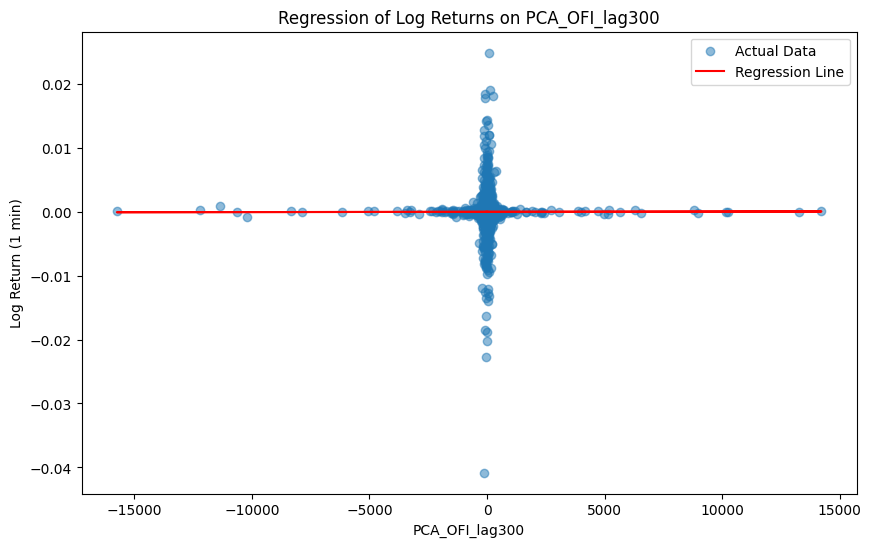

In [40]:
aep_cont_cross_5min = contemporaneous_cross_impact(aep_returns, 300)
aep_r2.append(aep_cont_cross_5min[0])
r2_dict['AEP'] = aep_r2
aep_cont_cross_5min

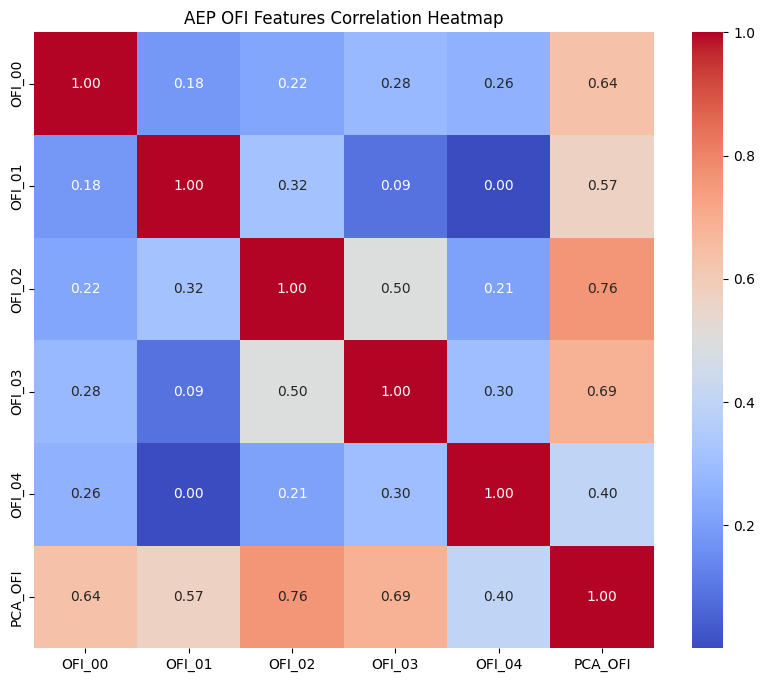

In [41]:
aep_df = aep_returns.dropna(subset=[f'OFI_{i:02d}' for i in range(5)])
ofi_cols_aep = [f'OFI_{i:02d}' for i in range(5)] + ["PCA_OFI"]
aep_df = aep_df[ofi_cols_aep].dropna()
plot_heatmap(aep_df, "AEP OFI Features Correlation Heatmap")

# <u>**AMGN**</u>

In [42]:
amgn_data = combined_df[combined_df['symbol'] == 'AMGN']
amgn_data = amgn_data[amgn_data['action'].isin(['A', 'T'])]
columns_to_keep = ['ts_event'] + [
    f'{header}_{i:02}'
    for i in range(5) # 00 to 04
    for header in ['bid_px', 'ask_px', 'bid_sz', 'ask_sz']
]
amgn_simplified = amgn_data[columns_to_keep]
amgn_simplified.loc[:, 'ts_event'] = pd.to_datetime(amgn_simplified['ts_event'])
amgn_simplified.set_index("ts_event", inplace=True)
amgn_simplified = amgn_simplified.resample("T").mean().reset_index()
amgn_simplified.head()

,ts_event,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_px_01,ask_px_01,bid_sz_01,ask_sz_01,bid_px_02,...,bid_sz_02,ask_sz_02,bid_px_03,ask_px_03,bid_sz_03,ask_sz_03,bid_px_04,ask_px_04,bid_sz_04,ask_sz_04
0,2024-12-09 09:00:00+00:00,270.98,NaN,25.000000,0.000000,NaN,NaN,0.000000,0.000000,NaN,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0
1,2024-12-09 09:01:00+00:00,240.00,NaN,2.000000,0.000000,NaN,NaN,0.000000,0.000000,NaN,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0
2,2024-12-09 09:02:00+00:00,250.86,273.40,1.666667,0.666667,240.00,274.210000,0.666667,1.333333,NaN,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0
3,2024-12-09 09:03:00+00:00,272.58,NaN,1.000000,0.000000,271.49,NaN,25.000000,0.000000,240.0,...,2.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0
4,2024-12-09 09:04:00+00:00,240.00,274.21,2.000000,354.100000,NaN,274.221724,0.000000,26.800000,NaN,...,0.0,14.5,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0


In [43]:
amgn_ofi_data = calculate_ofi(amgn_simplified)
amgn_ofi_data.head(25)

,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,ts_event
0,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:00:00
1,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:01:00
2,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:02:00
3,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:03:00
4,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:04:00
5,5.843590,NaN,NaN,NaN,NaN,2024-12-09 09:05:00
6,-98.923077,-55.076923,71.538462,33.333333,NaN,2024-12-09 09:06:00
7,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:07:00
8,NaN,NaN,NaN,NaN,NaN,2024-12-09 09:08:00
9,-12.000000,0.000000,49.000000,24.500000,-24.5,2024-12-09 09:09:00


In [44]:
amgn_pca_data = perform_pca_on_ofi(amgn_ofi_data)
amgn_pca_data

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI
0,2024-12-09 09:09:00,-12.000000,0.000000,49.000000,24.500000,-24.500000,24.183522
1,2024-12-09 09:16:00,0.000000,0.000000,0.000000,0.000000,0.000000,-7.562746
2,2024-12-09 09:17:00,0.000000,0.000000,0.000000,0.000000,0.000000,-7.562746
3,2024-12-09 09:20:00,-123.500000,-2.500000,117.500000,-35.000000,-43.500000,5.917094
4,2024-12-09 09:21:00,-12.000000,-111.500000,125.000000,8.500000,-43.500000,-0.039623
...,...,...,...,...,...,...,...
10868,2025-01-08 21:07:00,-1.000000,0.000000,0.000000,-0.500000,-11.500000,-10.720891
10869,2025-01-08 21:22:00,0.000000,0.000000,0.000000,0.000000,0.000000,-7.562746
10870,2025-01-08 21:35:00,38.166667,0.600000,-6.200000,-37.500000,15.633333,-11.806936
10871,2025-01-08 23:11:00,-0.366667,10.366667,10.983333,-1.216667,0.166667,4.523879


In [45]:
amgn_returns = calculate_returns(amgn_simplified, amgn_pca_data)
amgn_returns

,ts_event,OFI_00,OFI_01,OFI_02,OFI_03,OFI_04,PCA_OFI,log_return_1min
0,2024-12-09 09:09:00,-12.000000,0.000000,49.000000,24.500000,-24.500000,24.183522,-0.000815
1,2024-12-09 09:16:00,0.000000,0.000000,0.000000,0.000000,0.000000,-7.562746,0.000000
2,2024-12-09 09:17:00,0.000000,0.000000,0.000000,0.000000,0.000000,-7.562746,0.000000
3,2024-12-09 09:20:00,-123.500000,-2.500000,117.500000,-35.000000,-43.500000,5.917094,-0.000991
4,2024-12-09 09:21:00,-12.000000,-111.500000,125.000000,8.500000,-43.500000,-0.039623,0.000367
...,...,...,...,...,...,...,...,...
10868,2025-01-08 21:07:00,-1.000000,0.000000,0.000000,-0.500000,-11.500000,-10.720891,0.000095
10869,2025-01-08 21:22:00,0.000000,0.000000,0.000000,0.000000,0.000000,-7.562746,0.000000
10870,2025-01-08 21:35:00,38.166667,0.600000,-6.200000,-37.500000,15.633333,-11.806936,-0.001072
10871,2025-01-08 23:11:00,-0.366667,10.366667,10.983333,-1.216667,0.166667,4.523879,-0.000021


({'r2': 9.763035174858992e-06,
  'coef_PCA_OFI': np.float64(1.3643703363730257e-08)},
 <Figure size 1000x600 with 1 Axes>)

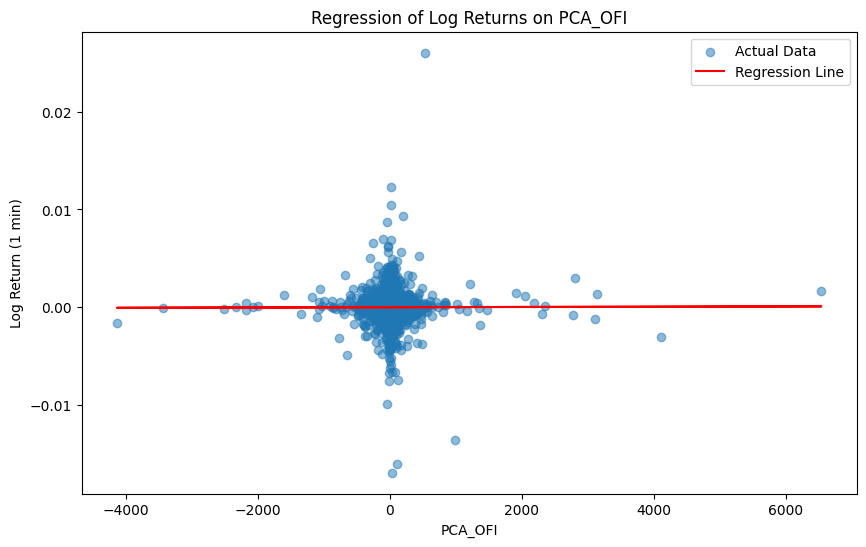

In [46]:
amgn_cont_cross = contemporaneous_cross_impact(amgn_returns)
amgn_r2 = []
amgn_r2.append(amgn_cont_cross[0])
amgn_cont_cross

({'r2': 2.1140000485364574e-05,
  'coef_PCA_OFI': np.float64(-2.0236236174691118e-08)},
 <Figure size 1000x600 with 1 Axes>)

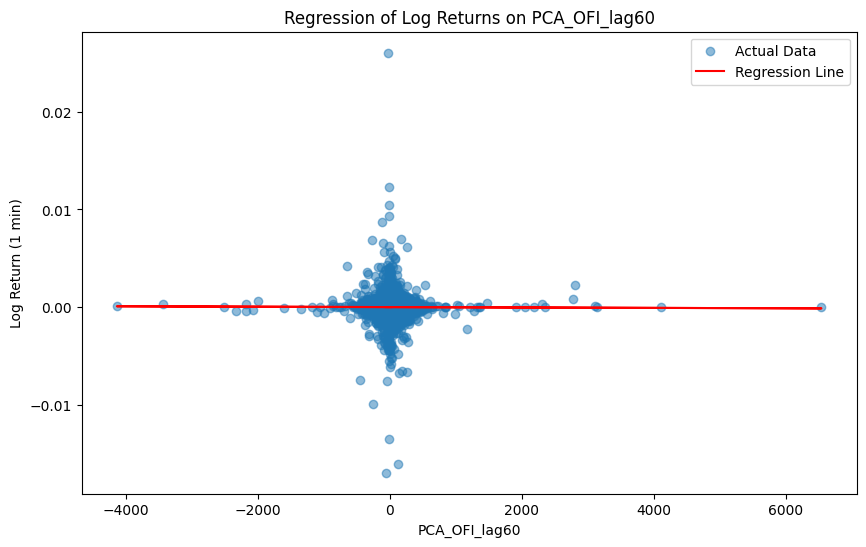

In [47]:
amgn_cont_cross_1min = contemporaneous_cross_impact(amgn_returns, 60)
amgn_r2.append(amgn_cont_cross_1min[0])
amgn_cont_cross_1min

({'r2': 7.897703828696478e-06,
  'coef_PCA_OFI': np.float64(-1.2280421725605297e-08)},
 <Figure size 1000x600 with 1 Axes>)

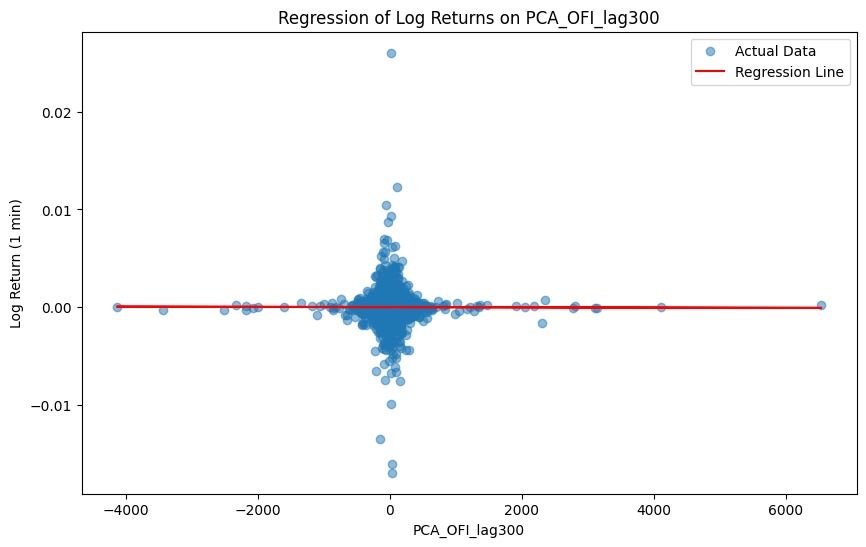

In [48]:
amgn_cont_cross_5min = contemporaneous_cross_impact(amgn_returns, 300)
amgn_r2.append(amgn_cont_cross_5min[0])
r2_dict['AMGN'] = amgn_r2
amgn_cont_cross_5min

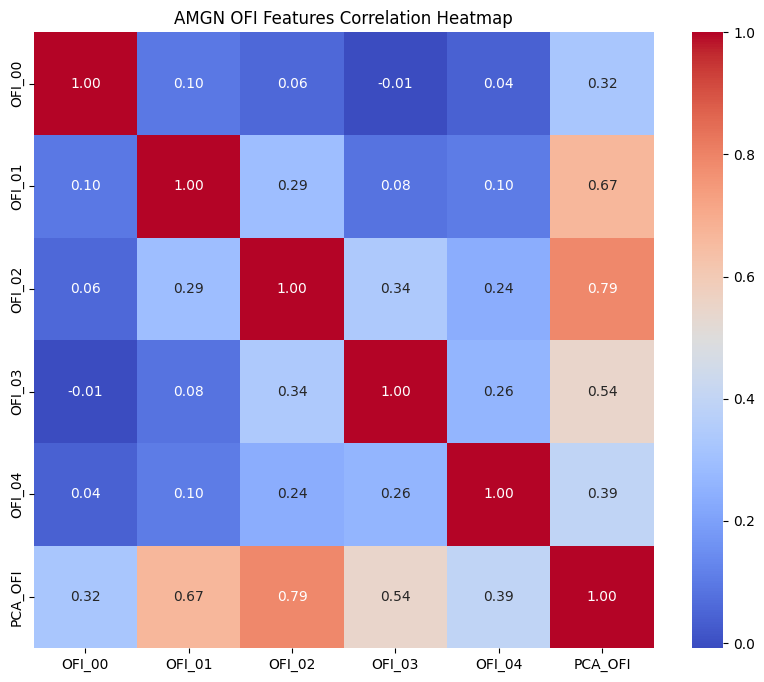

In [49]:
amgn_df = amgn_returns.dropna(subset=[f'OFI_{i:02d}' for i in range(5)])
ofi_cols_amgn = [f'OFI_{i:02d}' for i in range(5)] + ["PCA_OFI"]
amgn_df = amgn_df[ofi_cols_amgn].dropna()
plot_heatmap(amgn_df, "AMGN OFI Features Correlation Heatmap")

# Cross-Ticker Correlation
This section analyzes the correlation integrated order flow imbalance has on each other at 0, 1, and 5 minute lags. This will reveal potential impacts order flow imbalances in one sector (or ticker) have on other(s).

In [50]:
dfs = [aapl_pca_data, tsla_pca_data, amgn_pca_data, cost_pca_data, aep_pca_data]
stocks = ['AAPL', 'TSLA', 'AMGN', 'COST', 'AEP']
for df, stock in zip(dfs, stocks):
    if 'ts_event' in df.columns:
        df.set_index('ts_event', inplace=True)
    df.rename(columns={'PCA_OFI': f'PCA_OFI_{stock}'}, inplace=True)
    df[f'PCA_OFI_{stock}_lag60'] = df[f'PCA_OFI_{stock}'].shift(periods=1, freq='60S')
    df[f'PCA_OFI_{stock}_lag300'] = df[f'PCA_OFI_{stock}'].shift(periods=1, freq='300S')
    df.drop(columns=[col for col in df.columns if col.startswith('OFI_')], inplace=True)
cross_df = pd.concat(dfs, axis=1)
cross_df = cross_df.dropna()
cross_df

,PCA_OFI_AAPL,PCA_OFI_AAPL_lag60,PCA_OFI_AAPL_lag300,PCA_OFI_TSLA,PCA_OFI_TSLA_lag60,PCA_OFI_TSLA_lag300,PCA_OFI_AMGN,PCA_OFI_AMGN_lag60,PCA_OFI_AMGN_lag300,PCA_OFI_COST,PCA_OFI_COST_lag60,PCA_OFI_COST_lag300,PCA_OFI_AEP,PCA_OFI_AEP_lag60,PCA_OFI_AEP_lag300
ts_event,,,,,,,,,,,,,,,
2024-12-09 14:32:00,-123.786995,-131.753846,-490.317981,-105.295199,58.893686,72.735337,-70.291841,-86.643671,149.508068,22.292155,34.970432,-20.498853,170.829889,-59.083185,-437.080547
2024-12-09 14:33:00,-3.503612,-123.786995,929.500426,-134.782352,-105.295199,237.642063,12.163176,-70.291841,78.630784,-26.111900,22.292155,-1.744240,97.224844,170.829889,-1453.234736
2024-12-09 14:36:00,-128.455462,-3.071164,-131.753846,-11586.350665,11672.933950,58.893686,-84.770295,54.732928,-86.643671,-264.035457,-98.764308,34.970432,44.079916,141.239995,-59.083185
2024-12-09 14:37:00,-105.835866,-128.455462,-123.786995,37.423297,-11586.350665,-105.295199,-46.620649,-84.770295,-70.291841,-348.367442,-264.035457,22.292155,85.497708,44.079916,170.829889
2024-12-09 14:38:00,-89.464975,-105.835866,-3.503612,-36.891224,37.423297,-134.782352,51.997150,-46.620649,12.163176,20.844977,-348.367442,-26.111900,-149.646670,85.497708,97.224844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-08 20:56:00,-97.327404,-168.227963,-71.079325,-17.917270,-83.258313,-274.857771,-152.169931,102.281882,23.342554,122.936114,163.503253,-42.962369,21.287517,27.294050,42.273190
2025-01-08 20:57:00,-96.678133,-97.327404,-14.554599,-89.628473,-17.917270,117.422402,58.955729,-152.169931,-28.416663,49.379498,122.936114,57.369698,268.036988,21.287517,74.704941
2025-01-08 20:58:00,-191.444473,-96.678133,-83.929061,-227.965067,-89.628473,21.634283,93.772485,58.955729,46.016208,-404.991640,49.379498,24.485926,492.000683,268.036988,-63.732102


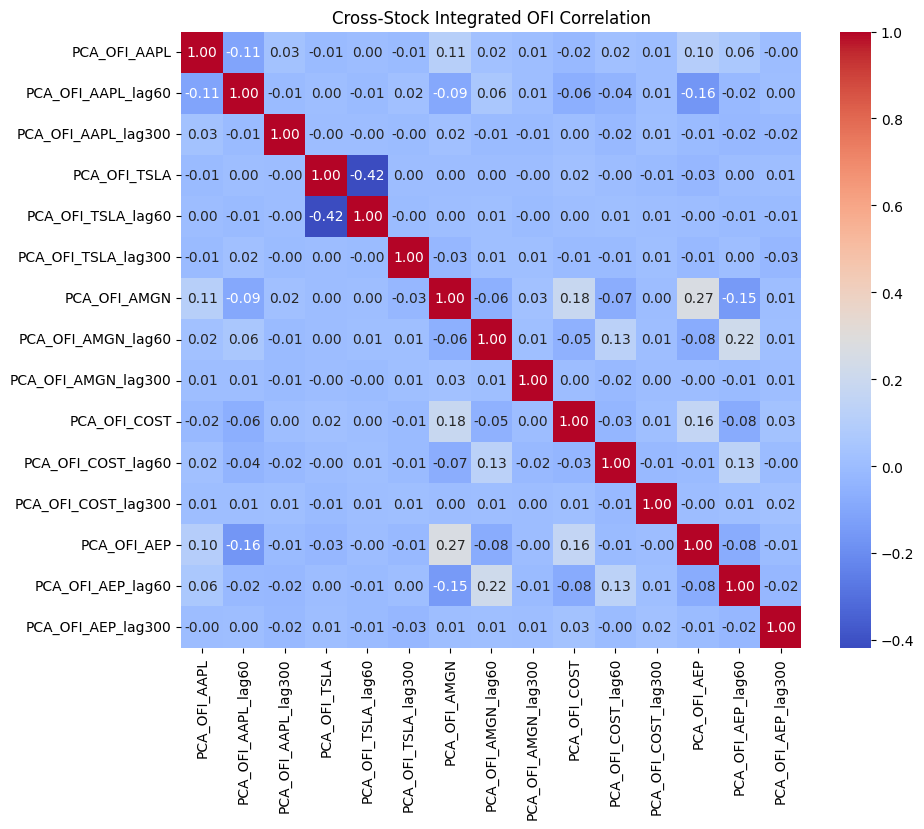

In [51]:
plot_heatmap(cross_df, "Cross-Stock Integrated OFI Correlation")

# <u>**R<sup>2</sup> Across Assets and Lags**</u>

In [52]:
r2_dict

{'AAPL': [{'r2': 3.2789674101474375e-06,
   'coef_PCA_OFI': np.float64(-2.8115001900224057e-10)},
  {'r2': 0.0002096296911113793,
   'coef_PCA_OFI': np.float64(-2.2430753667510165e-09)},
  {'r2': 0.0001301548086392046,
   'coef_PCA_OFI': np.float64(1.7663982824331818e-09)}],
 'TSLA': [{'r2': 3.818580372194624e-05,
   'coef_PCA_OFI': np.float64(-7.746378262920397e-09)},
  {'r2': 2.8891339734937738e-05,
   'coef_PCA_OFI': np.float64(-6.734770458447938e-09)},
  {'r2': 4.089909901194844e-06,
   'coef_PCA_OFI': np.float64(2.530347891306303e-09)}],
 'COST': [{'r2': 5.764322290824353e-06,
   'coef_PCA_OFI': np.float64(-1.302396721376078e-08)},
  {'r2': 6.9856542422863654e-06,
   'coef_PCA_OFI': np.float64(-1.368386963924903e-08)},
  {'r2': 9.497538134839445e-07,
   'coef_PCA_OFI': np.float64(-5.080201798928093e-09)}],
 'AEP': [{'r2': 0.0020176979477943835,
   'coef_PCA_OFI': np.float64(1.1280192643369599e-07)},
  {'r2': 0.0007738624801657545,
   'coef_PCA_OFI': np.float64(6.955475241388906e-0

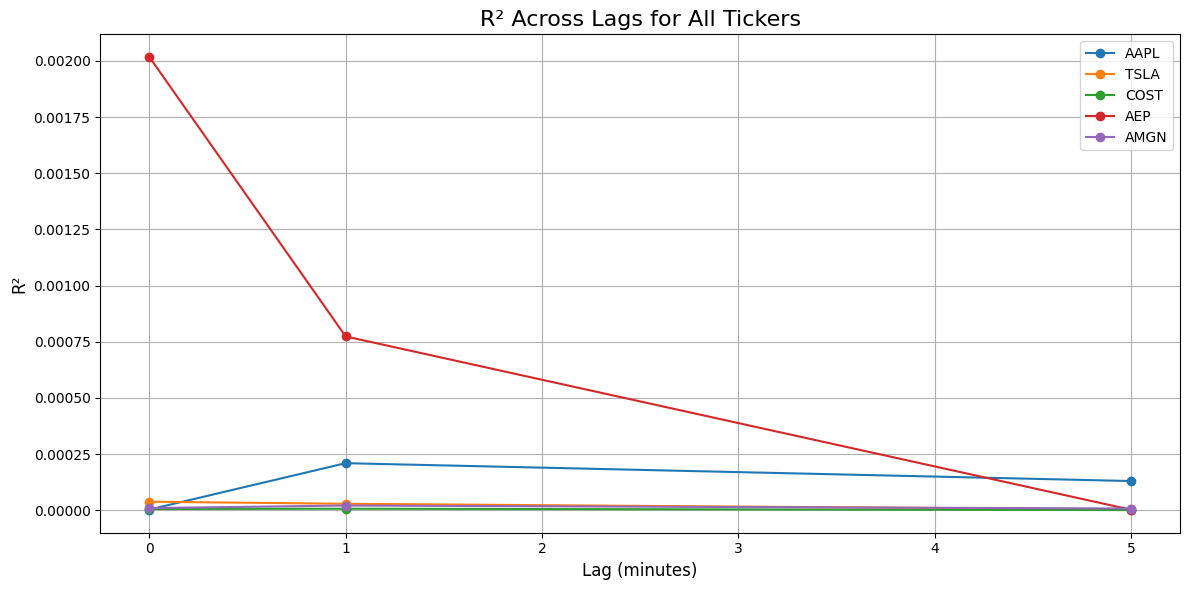

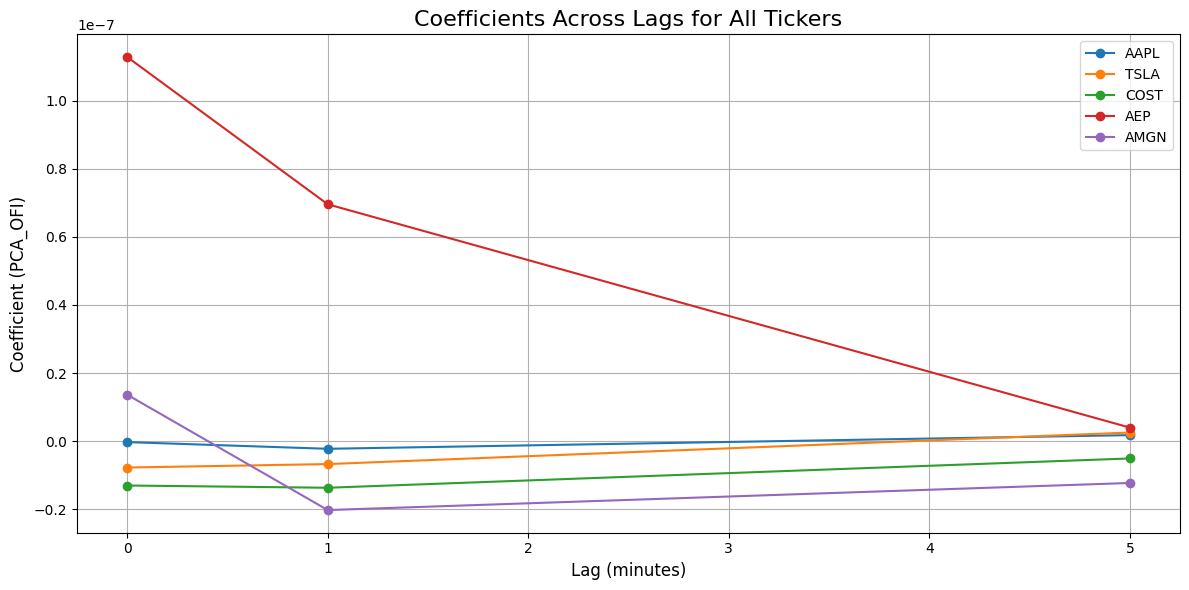

In [53]:
lags = [0, 1, 5]
plt.figure(figsize=(12, 6))
for ticker, values in r2_dict.items():
    r2_values = [entry['r2'] for entry in values]
    plt.plot(lags, r2_values, marker='o', label=f'{ticker}')
plt.title("R² Across Lags for All Tickers", fontsize=16)
plt.xlabel("Lag (minutes)", fontsize=12)
plt.ylabel("R²", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for ticker, values in r2_dict.items():
    coef_values = [entry['coef_PCA_OFI'] for entry in values]
    plt.plot(lags, coef_values, marker='o', label=f'{ticker}')
plt.title("Coefficients Across Lags for All Tickers", fontsize=16)
plt.xlabel("Lag (minutes)", fontsize=12)
plt.ylabel("Coefficient (PCA_OFI)", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()